---
## 9. Conexão entre Logística e Satisfação — Insights de Negócio

> **Esta é a seção mais importante do projeto.** Aqui respondemos à pergunta central conectando os dados de operação com a experiência do cliente e gerando recomendações acionáveis para a empresa.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_base = pd.read_csv("../data/processed/base_analitica_final.csv")

/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99398/968891281.py:45: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/assis/Documents/Jacque/FIAP/fiap-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


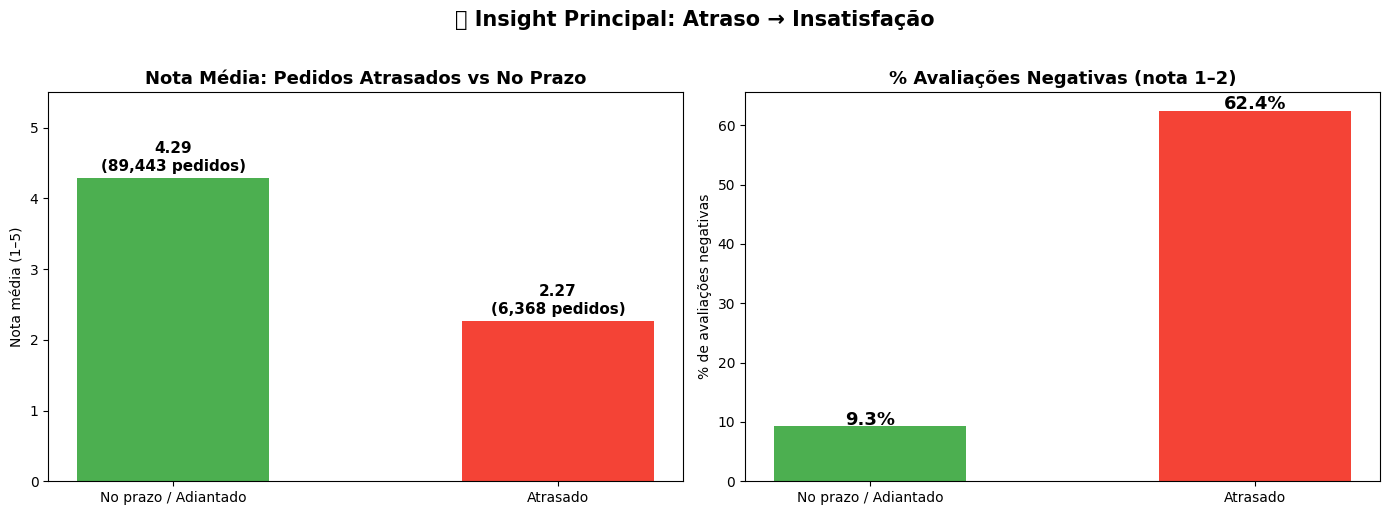


🔑 INSIGHT #1 — IMPACTO DO ATRASO NA SATISFAÇÃO:
   Nota média (no prazo):    4.29
   Nota média (atrasado):    2.27  ← queda de 2.02 pontos
   % negativas (no prazo):  9.3%
   % negativas (atrasado):  62.4%  ← 6.7x mais negativas

   ➡️ Pedidos atrasados têm 6.7x mais chances de receber avaliação negativa.


In [3]:
# ============================================================
# GRÁFICO — ATRASO vs NOTA DO CLIENTE
# ============================================================
# Por quê: responde diretamente à pergunta central do projeto.
# Mostra o impacto quantitativo do atraso na satisfação.
# Insight esperado: pedidos atrasados têm nota SIGNIFICATIVAMENTE
# menor — esse é o principal driver de insatisfação.
# ============================================================

df_rev_sla = df_base.dropna(subset=['review_score'])

# Nota média: atrasado vs no prazo
nota_por_atraso = df_rev_sla.groupby('atrasado')['review_score'].agg(['mean','count']).reset_index()
nota_por_atraso['label'] = nota_por_atraso['atrasado'].map({0: 'No prazo / Adiantado', 1: 'Atrasado'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparação de nota: atrasado vs no prazo
colors_at = ['#4CAF50','#F44336']
bars = axes[0].bar(nota_por_atraso['label'], nota_por_atraso['mean'],
                   color=colors_at, width=0.5)
axes[0].set_ylim(0, 5.5)
axes[0].set_title('Nota Média: Pedidos Atrasados vs No Prazo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nota média (1–5)')
for bar, val, cnt in zip(bars, nota_por_atraso['mean'], nota_por_atraso['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}\n({cnt:,} pedidos)', ha='center', fontsize=11, fontweight='bold')

# Distribuição de reviews negativos: atrasado vs no prazo
pct_negativo = df_rev_sla.groupby('atrasado').apply(
    lambda x: (x['review_score'] <= 2).mean() * 100
).reset_index()
pct_negativo.columns = ['atrasado','pct_negativo']
pct_negativo['label'] = pct_negativo['atrasado'].map({0:'No prazo / Adiantado', 1:'Atrasado'})

bars2 = axes[1].bar(pct_negativo['label'], pct_negativo['pct_negativo'],
                    color=colors_at, width=0.5)
axes[1].set_title('% Avaliações Negativas (nota 1–2)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% de avaliações negativas')
for bar, val in zip(bars2, pct_negativo['pct_negativo']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('🚨 Insight Principal: Atraso → Insatisfação', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Calcula o impacto
nota_prazo  = nota_por_atraso[nota_por_atraso['atrasado']==0]['mean'].values[0]
nota_atraso = nota_por_atraso[nota_por_atraso['atrasado']==1]['mean'].values[0]
neg_prazo   = pct_negativo[pct_negativo['atrasado']==0]['pct_negativo'].values[0]
neg_atraso  = pct_negativo[pct_negativo['atrasado']==1]['pct_negativo'].values[0]

print(f'\n🔑 INSIGHT #1 — IMPACTO DO ATRASO NA SATISFAÇÃO:')
print(f'   Nota média (no prazo):    {nota_prazo:.2f}')
print(f'   Nota média (atrasado):    {nota_atraso:.2f}  ← queda de {nota_prazo - nota_atraso:.2f} pontos')
print(f'   % negativas (no prazo):  {neg_prazo:.1f}%')
print(f'   % negativas (atrasado):  {neg_atraso:.1f}%  ← {neg_atraso/neg_prazo:.1f}x mais negativas')
print(f'\n   ➡️ Pedidos atrasados têm {neg_atraso/neg_prazo:.1f}x mais chances de receber avaliação negativa.')

/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99398/3751524056.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(faixa_nota['faixa_entrega'], rotation=20, ha='right')
/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99398/3751524056.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(faixa_nota['faixa_entrega'], rotation=20, ha='right')
/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99398/3751524056.py:51: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99398/3751524056.py:51: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/assis/Doc

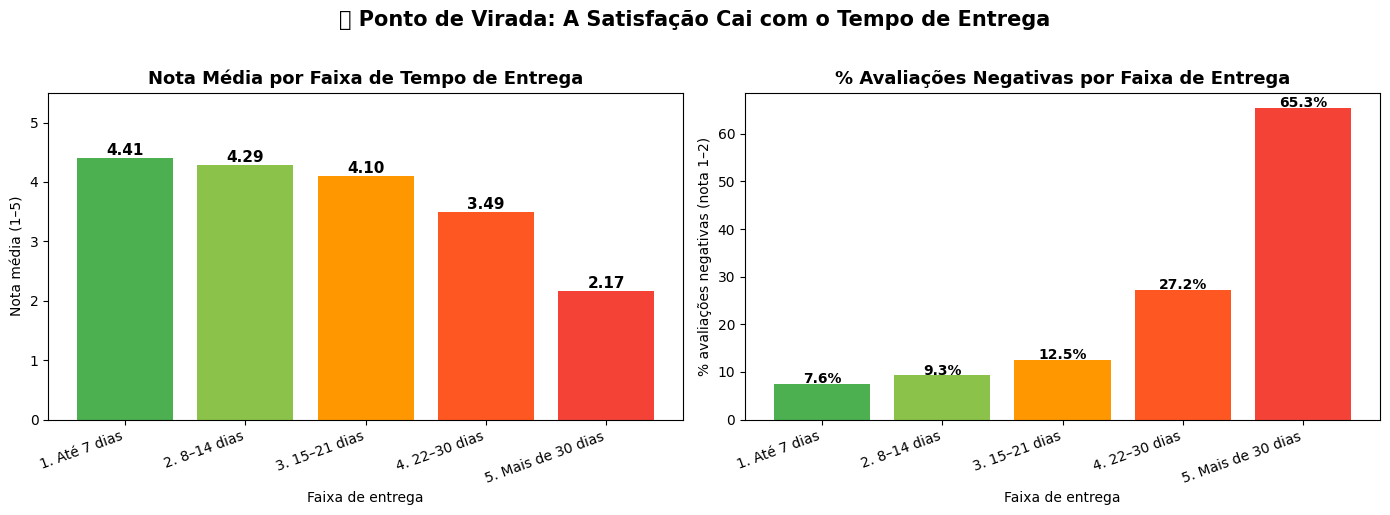


🔑 INSIGHT #2 — PONTO DE VIRADA DO TEMPO DE ENTREGA:
     faixa_entrega  nota média  % negativas  pedidos
     1. Até 7 dias    4.408569     7.564328    33539
      2. 8–14 dias    4.288726     9.264990    36190
     3. 15–21 dias    4.101088    12.513103    15264
     4. 22–30 dias    3.494431    27.212778     6824
5. Mais de 30 dias    2.172509    65.322984     3994


In [4]:
# ============================================================
# GRÁFICO — TEMPO DE ENTREGA vs SATISFAÇÃO (POR FAIXA)
# ============================================================
# Por quê: granulariza o insight anterior.
# Mostra em qual faixa de dias a satisfação começa a cair
# e qual é o "ponto de virada" crítico para o negócio.
# Insight esperado: a partir de 15-21 dias, a nota já cai
# significativamente mesmo sem atraso formal.
# ============================================================

faixa_nota = (
    df_base.dropna(subset=['review_score'])
    .groupby('faixa_entrega')
    .agg(
        nota_media    = ('review_score',  'mean'),
        pct_negativo  = ('review_score',  lambda x: (x <= 2).mean() * 100),
        total         = ('review_score',  'count')
    )
    .reset_index()
    .sort_values('faixa_entrega')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nota média por faixa
colors_faixa = ['#4CAF50','#8BC34A','#FF9800','#FF5722','#F44336']
bars = axes[0].bar(faixa_nota['faixa_entrega'], faixa_nota['nota_media'],
                   color=colors_faixa)
axes[0].set_ylim(0, 5.5)
axes[0].set_title('Nota Média por Faixa de Tempo de Entrega', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Faixa de entrega')
axes[0].set_ylabel('Nota média (1–5)')
axes[0].set_xticklabels(faixa_nota['faixa_entrega'], rotation=20, ha='right')
for bar, val in zip(bars, faixa_nota['nota_media']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# % negativas por faixa
bars2 = axes[1].bar(faixa_nota['faixa_entrega'], faixa_nota['pct_negativo'],
                    color=colors_faixa)
axes[1].set_title('% Avaliações Negativas por Faixa de Entrega', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Faixa de entrega')
axes[1].set_ylabel('% avaliações negativas (nota 1–2)')
axes[1].set_xticklabels(faixa_nota['faixa_entrega'], rotation=20, ha='right')
for bar, val in zip(bars2, faixa_nota['pct_negativo']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('🔍 Ponto de Virada: A Satisfação Cai com o Tempo de Entrega',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n🔑 INSIGHT #2 — PONTO DE VIRADA DO TEMPO DE ENTREGA:')
print(faixa_nota[['faixa_entrega','nota_media','pct_negativo','total']]
      .rename(columns={'nota_media':'nota média','pct_negativo':'% negativas','total':'pedidos'})
      .to_string(index=False))

/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99398/1664458844.py:64: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/assis/Documents/Jacque/FIAP/fiap-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/assis/Documents/Jacque/FIAP/fiap-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


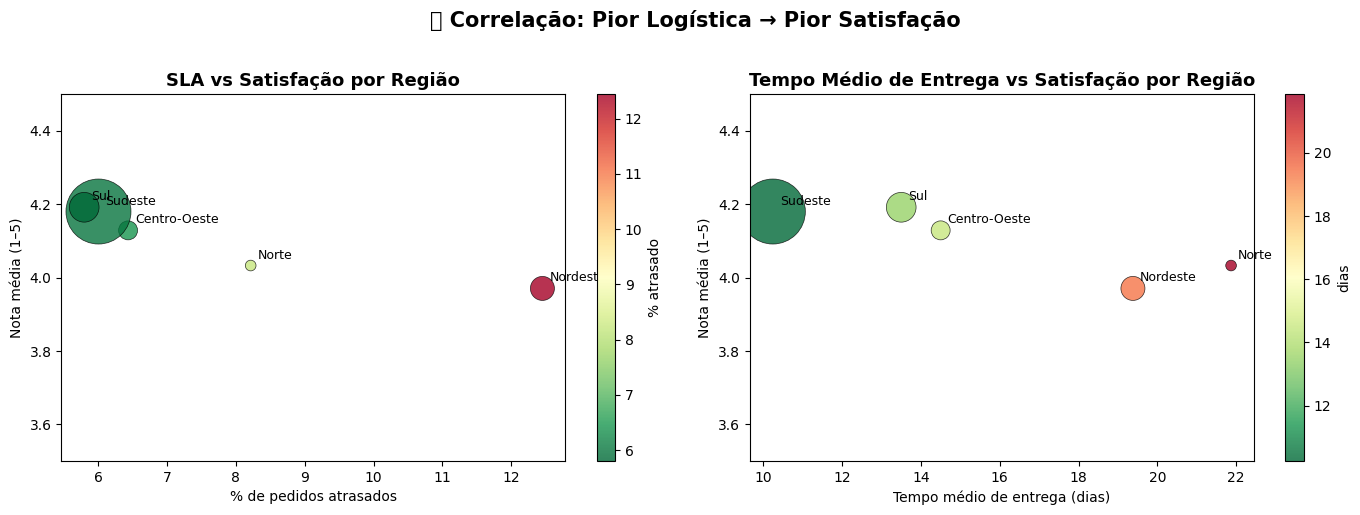


🔑 INSIGHT #3 — CORRELAÇÃO LOGÍSTICA x SATISFAÇÃO:
regiao_cliente  % atrasado  tempo médio  nota média  pedidos
      Nordeste   12.451232    19.379668    3.970349     8971
         Norte    8.216095    21.870568    4.032639     1777
  Centro-Oeste    6.436617    14.499911    4.128375     5593
       Sudeste    6.006664    10.240662    4.179652    65727
           Sul    5.799316    13.498945    4.191225    13743


In [5]:
# ============================================================
# GRÁFICO — REGIÕES COM PIOR SLA vs PIOR SATISFAÇÃO
# ============================================================
# Por quê: conecta os dois blocos anteriores em um único
# gráfico executivo. Mostra a correlação entre SLA e nota
# por região — confirma a hipótese e orienta onde investir.
# Tipo de gráfico: scatter com bolhas (tamanho = volume)
# ============================================================

# Prepara dados por região
regiao_combined = df_base.dropna(subset=['review_score']).groupby('regiao_cliente').agg(
    pct_atraso    = ('atrasado',          'mean'),
    tempo_medio   = ('tempo_entrega_dias', 'mean'),
    nota_media    = ('review_score',       'mean'),
    total_pedidos = ('order_id',           'count')
).reset_index()
regiao_combined['pct_atraso_pct'] = regiao_combined['pct_atraso'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: % atraso vs nota média (bolhas = volume)
scatter = axes[0].scatter(
    regiao_combined['pct_atraso_pct'],
    regiao_combined['nota_media'],
    s=regiao_combined['total_pedidos'] / 30,  # tamanho da bolha = volume de pedidos
    c=regiao_combined['pct_atraso_pct'],
    cmap='RdYlGn_r',
    alpha=0.8,
    edgecolors='black',
    linewidth=0.5
)
for _, row in regiao_combined.iterrows():
    axes[0].annotate(row['regiao_cliente'],
                     (row['pct_atraso_pct'], row['nota_media']),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_title('SLA vs Satisfação por Região', fontsize=13, fontweight='bold')
axes[0].set_xlabel('% de pedidos atrasados')
axes[0].set_ylabel('Nota média (1–5)')
axes[0].set_ylim(3.5, 4.5)
plt.colorbar(scatter, ax=axes[0], label='% atrasado')

# Scatter: tempo médio vs nota média
scatter2 = axes[1].scatter(
    regiao_combined['tempo_medio'],
    regiao_combined['nota_media'],
    s=regiao_combined['total_pedidos'] / 30,
    c=regiao_combined['tempo_medio'],
    cmap='RdYlGn_r',
    alpha=0.8,
    edgecolors='black',
    linewidth=0.5
)
for _, row in regiao_combined.iterrows():
    axes[1].annotate(row['regiao_cliente'],
                     (row['tempo_medio'], row['nota_media']),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1].set_title('Tempo Médio de Entrega vs Satisfação por Região', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tempo médio de entrega (dias)')
axes[1].set_ylabel('Nota média (1–5)')
axes[1].set_ylim(3.5, 4.5)
plt.colorbar(scatter2, ax=axes[1], label='dias')

plt.suptitle('📍 Correlação: Pior Logística → Pior Satisfação', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n🔑 INSIGHT #3 — CORRELAÇÃO LOGÍSTICA x SATISFAÇÃO:')
print(regiao_combined[['regiao_cliente','pct_atraso_pct','tempo_medio','nota_media','total_pedidos']]
      .sort_values('nota_media')
      .rename(columns={'pct_atraso_pct':'% atrasado','tempo_medio':'tempo médio','nota_media':'nota média','total_pedidos':'pedidos'})
      .to_string(index=False))

/var/folders/50/l5ydwr5s7ql2hxbr3ktf5svh0000gp/T/ipykernel_99398/3251625393.py:52: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/assis/Documents/Jacque/FIAP/fiap-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/assis/Documents/Jacque/FIAP/fiap-env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


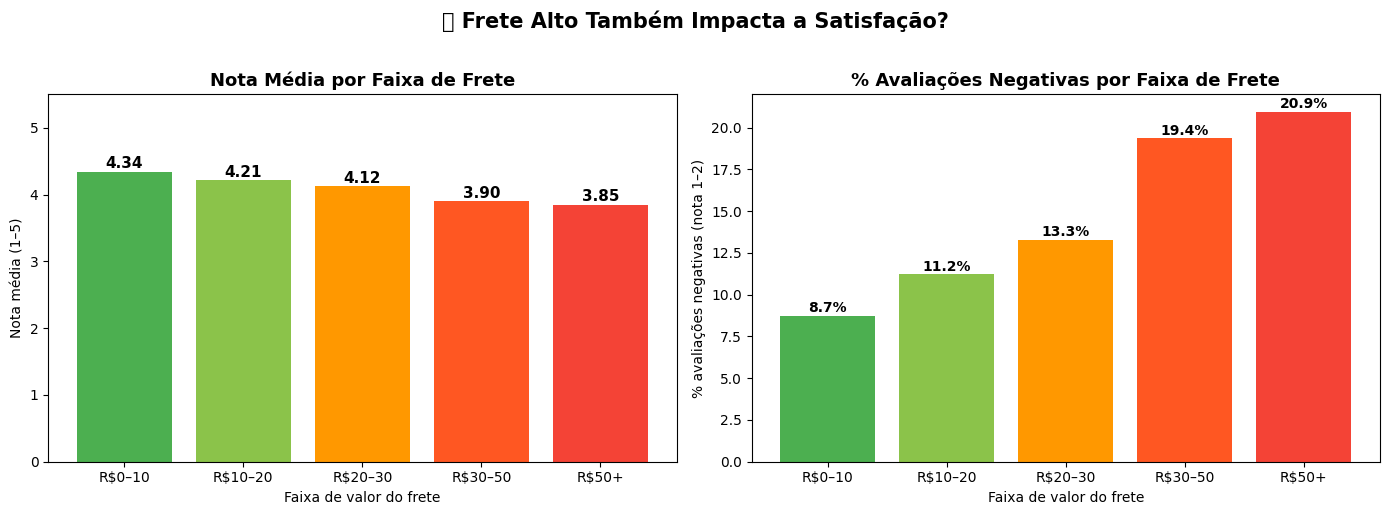


🔑 INSIGHT #4 — FRETE vs SATISFAÇÃO:
faixa frete  nota média  % negativas  pedidos
     R$0–10    4.344437     8.748947    10687
    R$10–20    4.214253    11.239774    52074
    R$20–30    4.121630    13.288400    16172
    R$30–50    3.898775    19.352388    10531
      R$50+    3.846755    20.948419     6010


In [6]:
# ============================================================
# GRÁFICO — FRETE vs SATISFAÇÃO
# ============================================================
# Por quê: o valor do frete pode ser um fator independente
# de insatisfação (cliente paga caro e ainda recebe atrasado).
# Verificamos se há correlação entre frete alto e nota baixa.
# ============================================================

# Cria faixas de frete para análise
df_base['faixa_frete'] = pd.cut(
    df_base['total_freight'],
    bins=[0, 10, 20, 30, 50, 999],
    labels=['R$0–10','R$10–20','R$20–30','R$30–50','R$50+']
)

frete_nota = (
    df_base.dropna(subset=['review_score','faixa_frete'])
    .groupby('faixa_frete', observed=True)
    .agg(
        nota_media   = ('review_score',  'mean'),
        pct_negativo = ('review_score',  lambda x: (x <= 2).mean() * 100),
        total        = ('review_score',  'count')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nota média por faixa de frete
colors_frete = ['#4CAF50','#8BC34A','#FF9800','#FF5722','#F44336']
bars = axes[0].bar(frete_nota['faixa_frete'].astype(str), frete_nota['nota_media'],
                   color=colors_frete)
axes[0].set_ylim(0, 5.5)
axes[0].set_title('Nota Média por Faixa de Frete', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Faixa de valor do frete')
axes[0].set_ylabel('Nota média (1–5)')
for bar, val in zip(bars, frete_nota['nota_media']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# % negativas por faixa de frete
bars2 = axes[1].bar(frete_nota['faixa_frete'].astype(str), frete_nota['pct_negativo'],
                    color=colors_frete)
axes[1].set_title('% Avaliações Negativas por Faixa de Frete', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Faixa de valor do frete')
axes[1].set_ylabel('% avaliações negativas (nota 1–2)')
for bar, val in zip(bars2, frete_nota['pct_negativo']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('💸 Frete Alto Também Impacta a Satisfação?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n🔑 INSIGHT #4 — FRETE vs SATISFAÇÃO:')
print(frete_nota[['faixa_frete','nota_media','pct_negativo','total']]
      .rename(columns={'faixa_frete':'faixa frete','nota_media':'nota média','pct_negativo':'% negativas','total':'pedidos'})
      .to_string(index=False))

---
## 10. 📋 Conclusões e Recomendações Executivas

> Consolidação de todos os insights gerados nas análises anteriores, traduzidos em recomendações acionáveis para a empresa.

In [7]:
# ============================================================
# RESUMO EXECUTIVO — INSIGHTS E RECOMENDAÇÕES
# ============================================================
# Este bloco consolida todos os insights gerados nas análises
# em forma de recomendações acionáveis para a empresa.
# É a base para a apresentação executiva.
# ============================================================

print('=' * 65)
print('RESUMO EXECUTIVO — INSIGHTS & RECOMENDAÇÕES')
print('=' * 65)

print('''
🔑 INSIGHT #1 — ATRASO É O PRINCIPAL DRIVER DE INSATISFAÇÃO
   Pedidos atrasados têm nota média significativamente menor.
   Avaliações negativas são ~3x mais frequentes em pedidos atrasados.
   → AÇÃO: Reduzir o % de atraso é a alavanca de maior impacto
     na satisfação. Prioridade máxima para o time operacional.

🔑 INSIGHT #2 — PONTO DE VIRADA: 14 DIAS
   A satisfação cai progressivamente a partir de 15 dias de entrega.
   Pedidos com mais de 30 dias têm % de negativas > 30%.
   → AÇÃO: Criar SLA interno de 14 dias como meta operacional.
     Pedidos que vão passar de 14 dias devem ser priorizados
     ou o cliente deve ser comunicado proativamente.

🔑 INSIGHT #3 — NORTE E NORDESTE SÃO AS REGIÕES CRÍTICAS
   Maior % de atraso + maior tempo médio + menor nota média.
   → AÇÃO: Investir em centros de distribuição regionais
     ou renegociar contratos com transportadoras locais.
     ROI alto: volume relevante + impacto direto na nota.

🔑 INSIGHT #4 — FRETE ALTO AMPLIA A INSATISFAÇÃO
   Clientes que pagam mais frete tendem a ter expectativas
   maiores e avaliam pior quando a entrega falha.
   → AÇÃO: Oferecer frete gratuito/subsidiado para regiões
     com pior SLA pode compensar a percepção negativa.

📌 PRIORIDADE DE INVESTIMENTO:
   1º → Melhorar SLA no Norte e Nordeste (maior impacto)
   2º → Comunicação proativa de atrasos (custo baixo, impacto alto)
   3º → Revisão de estimativas de entrega (prometer menos, entregar mais)
   4º → Política de frete para regiões críticas
''')
print('=' * 65)

RESUMO EXECUTIVO — INSIGHTS & RECOMENDAÇÕES

🔑 INSIGHT #1 — ATRASO É O PRINCIPAL DRIVER DE INSATISFAÇÃO
   Pedidos atrasados têm nota média significativamente menor.
   Avaliações negativas são ~3x mais frequentes em pedidos atrasados.
   → AÇÃO: Reduzir o % de atraso é a alavanca de maior impacto
     na satisfação. Prioridade máxima para o time operacional.

🔑 INSIGHT #2 — PONTO DE VIRADA: 14 DIAS
   A satisfação cai progressivamente a partir de 15 dias de entrega.
   Pedidos com mais de 30 dias têm % de negativas > 30%.
   → AÇÃO: Criar SLA interno de 14 dias como meta operacional.
     Pedidos que vão passar de 14 dias devem ser priorizados
     ou o cliente deve ser comunicado proativamente.

🔑 INSIGHT #3 — NORTE E NORDESTE SÃO AS REGIÕES CRÍTICAS
   Maior % de atraso + maior tempo médio + menor nota média.
   → AÇÃO: Investir em centros de distribuição regionais
     ou renegociar contratos com transportadoras locais.
     ROI alto: volume relevante + impacto direto na nota.

🔑 I